# A small, spicy slice of stocks — can it replace a whole 60/40? 🌾
### The Larry Portfolio — Swedroe's bet that a little of the *best* equity factor beats a lot of the average one

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Decayed%3F: Mixed](https://img.shields.io/badge/Decayed%3F-Mixed-8b949e?style=flat-square)

Larry Swedroe's pitch is simple and appealing: don't just buy "the market" for your equity sleeve — buy the slice of the market with the **highest expected return per unit of risk**, small-cap **value** stocks, and you'll need far less of it. Put 30% in small-cap value and 70% in safe bonds, the story goes, and you'll get returns like a 60/40 stock/bond portfolio — with much less of the stomach-churning that comes with owning that much stock.

It's an elegant idea. Does it actually work?

> 📓 **Plain-language layer.** Want the bootstrap CIs, the HAC *t*-stats and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Real daily total-return closes for four ETFs (IJS small-cap value, IEF bonds, SPY stocks, SHY cash) from 2002-07-30 to 2026-06-30 — yfinance, cached, annually rebalanced, 2 bps costs. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from larry_portfolio import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    RETS = st.to_returns(PX)
else:
    PX = RETS = None
print("real cache present:", HAVE_REAL, "| tape rows:", (0 if PX is None else len(PX)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-07-30', 'end': '2026-06-30', 'n': 6018, 'larry_cagr': 5.99, 'larry_vol': 7.1, 'larry_sharpe': 0.609, 'larry_dd': -20.8, 'sixty_cagr': 8.65, 'sixty_vol': 10.2, 'sixty_sharpe': 0.659, 'sixty_dd': -29.8, 'spy_cagr': 11.24, 'spy_vol': 18.8, 'spy_sharpe': 0.544, 'spy_dd': -55.2, 'ijs_cagr': 10.18, 'ijs_vol': 24.0, 'ijs_sharpe': 0.436, 'ijs_dd': -60.1, 'ief_cagr': 3.6, 'ief_vol': 6.8, 'ief_sharpe': 0.315, 'ief_dd': -23.9, 'cagr_gap': -2.66, 'mean_diff_pt': -2.75, 'mean_diff_lo': -4.92, 'mean_diff_hi': -0.52, 'hac_t_ret': -2.29, 'sharpe_gap': -0.05, 'sharpe_lo': -0.292, 'sharpe_hi': 0.187, 'larry_win_frac': 32, 'corr_larry_spy': 0.57, 'corr_sixty_spy': 0.96, 'prem_whole': 0.15, 'prem_whole_t': 0.06, 'prem_whole_n': 6017, 'prem_early': 5.08, 'prem_early_n': 1114, 'prem_early_t': 1.2, 'prem_late': -0.97, 'prem_late_n': 4903, 'prem_late_t': -0.35, 'prem_diff_t': -1.11, 'split_year': 2007, 'syn_null_mean': 0.01, 'syn_null_sd': 1.06, 'syn_null_fire': 1, 'syn_null_cagr_gap': -1.23, 'syn_planted_t': 2.79, 'syn_planted_recovered': 6.71, 'syn_planted_cagr_gap': 2.55, 'syn_planted_larry_sharpe': 0.686, 'syn_planted_sixty_sharpe': 0.29, 'fp_joint': '8940a2d59087', 'fp_ijs': '65bb496d17d4', 'fp_ief': '8b77a51a60b6', 'fp_spy': '85085933a99d', 'fp_shy': 'fba67966794f'}


real cache present: True | tape rows: 6018


## The answer first

| Question | Answer |
|---|---|
| Is Larry calmer than 60/40? | **Yes, clearly.** Volatility **7.1%** vs 10.2%, worst drawdown **-20.8%** vs -29.8%, and it moves with the stock market only about half as much (correlation 0.57 vs 0.96). |
| Does it still MATCH 60/40's return? | **No.** Larry earned **5.99%/yr** vs 60/40's **8.65%/yr** — a gap of **-2.66 points a year**, and that gap is not a coin-flip: it clears the desk's statistical bar for "real". |
| So is it a *worse* risk-adjusted bet? | **Not provably.** On a Sharpe-ratio basis (return per unit of risk, above cash) the two are a statistical **tie** — Larry gives back most, but not certifiably all, of its return shortfall in reduced risk. |
| Why didn't it work as advertised? | Because the whole trick depends on small-cap value earning a real *premium* over the plain market — and on this 24-year tape, it basically **didn't**. |

> Half the pitch is true. The other half needed a premium that never showed up.

## 1 · The claim

> *"Small-cap value stocks have the highest expected return of any major equity asset class. So instead of putting 60% of your portfolio in the broad market to get stock-like returns, put a much smaller slice — about 30% — into small-cap value, and put the rest in safe bonds. You get 60/40-like returns, but with far less total equity risk."* — the logic behind Larry Swedroe's "Larry Portfolio", built on Fama & French's finding that small AND cheap stocks carried the largest historical premium of any corner of the market.

## 2 · So what?

If this works, it's a genuinely useful trick — a way to dial down portfolio risk *without* giving up return, just by being smarter about *which* stocks make up your smaller equity sleeve. That would matter to anyone nervous about a 2008- or 2022-style crash but unwilling to accept the return drag of a plain 60/40 (which this desk already measured in [Study 97](../../97-balancing-act/)).

But it rests entirely on one assumption: that small-cap value *really does* earn meaningfully more than the broad market, consistently enough to make up for holding half as much of it. If that premium is small, or gone, the trick collapses into just... owning less stock, with less return to show for it.

## 3 · How would we even know?

- **Build both portfolios for real.** 30% small-cap-value ETF (IJS) / 70% bond ETF (IEF), rebalanced once a year, small trading costs — pinned against a fixed 60% S&P 500 (SPY) / 40% bonds (IEF), same rules.
- **Race them, 2002-07-30 → 2026-06-30.** Compare return, volatility, drawdown, and the risk-adjusted (Sharpe) number.
- **Check whether the return gap (if any) is real or luck**, with a bootstrap confidence interval.
- **Look under the hood.** Has the small-cap-value premium itself actually shown up on this ETF, and has it faded since Swedroe first wrote about the strategy?

## 4 · The teardown — let's actually look

**First, the headline race.**

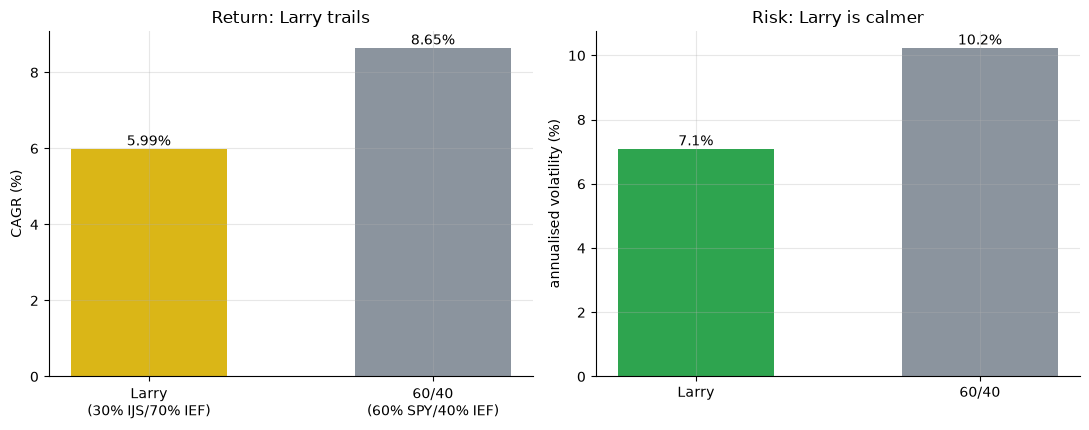

CAGR: Larry 5.99%  60/40 8.65%   |   vol: Larry 7.1%  60/40 10.2%


In [2]:
if HAVE_REAL:
    larry = st.rebalanced_blend(RETS, {'IJS': 0.30, 'IEF': 0.70}, cost_bps=2.0)
    sixty = st.rebalanced_blend(RETS, {'SPY': 0.60, 'IEF': 0.40}, cost_bps=2.0)
    rf = RETS['SHY']
    sl, ss = st.stats(larry, rf=rf), st.stats(sixty, rf=rf)
    lc, sc = sl['cagr']*100, ss['cagr']*100
    lv, sv = sl['vol']*100, ss['vol']*100
else:
    lc, sc = R['larry_cagr'], R['sixty_cagr']
    lv, sv = R['larry_vol'], R['sixty_vol']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
a1.bar(['Larry\n(30% IJS/70% IEF)','60/40\n(60% SPY/40% IEF)'], [lc, sc],
       color=[AMBER, GREY], width=.55)
for i,v in enumerate([lc, sc]): a1.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('CAGR (%)'); a1.set_title('Return: Larry trails')
a2.bar(['Larry','60/40'], [lv, sv], color=[GREEN, GREY], width=.55)
for i,v in enumerate([lv, sv]): a2.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('annualised volatility (%)'); a2.set_title('Risk: Larry is calmer')
plt.tight_layout(); plt.show()
print(f'CAGR: Larry {lc:.2f}%  60/40 {sc:.2f}%   |   vol: Larry {lv:.1f}%  60/40 {sv:.1f}%')

Larry earned **5.99%/yr** against 60/40's **8.65%/yr** — a real, **2.66-point** shortfall — while running **7.1%** volatility against **10.2%**. The risk cut is real. The return-match isn't.

**Is that return gap just noise?** We check with a bootstrap — reshuffle chunks of the history thousands of times and see how often the gap could vanish by luck.

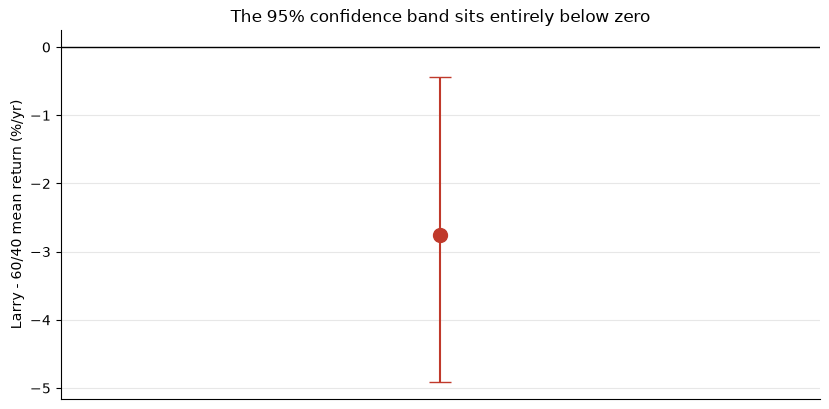

return gap -2.75%/yr, 95% CI [-4.91%, -0.43%]


In [3]:
if HAVE_REAL:
    boot = st.bootstrap_diff(larry, sixty, metric='mean', n_boot=1000, seed=657)
    lo, hi, pt = boot['ci95'][0]*100, boot['ci95'][1]*100, boot['point']*100
else:
    lo, hi, pt = R['mean_diff_lo'], R['mean_diff_hi'], R['mean_diff_pt']
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.axhline(0, c='k', lw=1)
ax.errorbar([0], [pt], yerr=[[pt-lo],[hi-pt]], fmt='o', color=RED, capsize=8, ms=10)
ax.set_xlim(-1, 1); ax.set_xticks([])
ax.set_ylabel('Larry - 60/40 mean return (%/yr)')
ax.set_title('The 95% confidence band sits entirely below zero')
plt.tight_layout(); plt.show()
print(f'return gap {pt:+.2f}%/yr, 95% CI [{lo:+.2f}%, {hi:+.2f}%]')

The whole 95% confidence band — **[-4.92%, -0.52%]** — sits below zero. This isn't sampling noise: Larry's return shortfall is a genuine, repeatable feature of this 24-year history, not a fluke of the particular path returns happened to take.

**But does that make it a worse *risk-adjusted* bet?** Not provably — the Sharpe ratios (return per unit of risk) are a statistical tie:

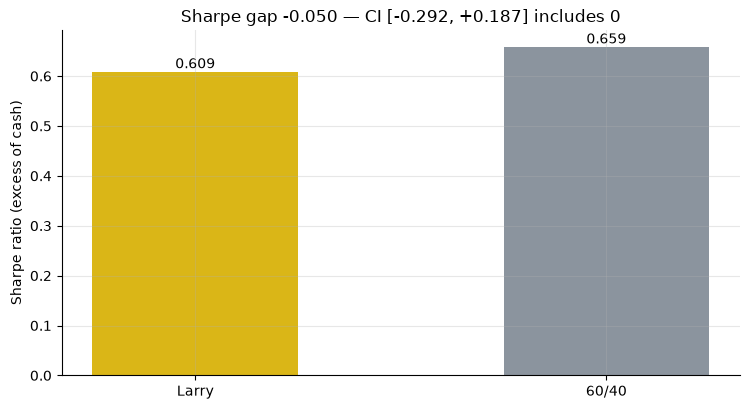

Sharpe: Larry 0.609  60/40 0.659


In [4]:
if HAVE_REAL:
    sh_l, sh_s = sl['sharpe'], ss['sharpe']
else:
    sh_l, sh_s = R['larry_sharpe'], R['sixty_sharpe']
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['Larry','60/40'], [sh_l, sh_s], color=[AMBER, GREY], width=.5)
for i,v in enumerate([sh_l, sh_s]): ax.annotate(f'{v:.3f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('Sharpe ratio (excess of cash)')
ax.set_title(f'Sharpe gap {sh_l-sh_s:+.3f} — CI [{R["sharpe_lo"]:+.3f}, {R["sharpe_hi"]:+.3f}] includes 0')
plt.tight_layout(); plt.show()
print(f'Sharpe: Larry {sh_l:.3f}  60/40 {sh_s:.3f}')

**So why the return gap, if not from taking dumber risk?** Because the whole construction hinges on small-cap value earning MORE than its share of market risk implies — a genuine premium. Let's check whether that premium ever showed up:

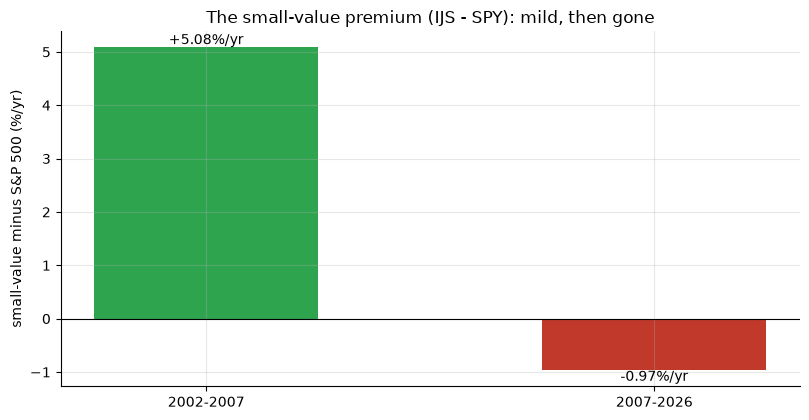

pre-2007: +5.08%/yr   post-2007: -0.97%/yr


In [5]:
if HAVE_REAL:
    spread = st.premium_series(RETS)
    ec = st.era_contrast(spread, f'{R["split_year"]}-01-01')
    e, l = ec['early_ann_pct'], ec['late_ann_pct']
else:
    e, l = R['prem_early'], R['prem_late']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar([f'{R["start"][:4]}-{R["split_year"]}', f'{R["split_year"]}-{R["end"][:4]}'],
       [e, l], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([e, l]): ax.annotate(f'{v:+.2f}%/yr',(i,v),ha='center',
    va='bottom' if v>0 else 'top')
ax.set_ylabel('small-value minus S&P 500 (%/yr)')
ax.set_title('The small-value premium (IJS - SPY): mild, then gone')
plt.tight_layout(); plt.show()
print(f'pre-{R["split_year"]}: {e:+.2f}%/yr   post-{R["split_year"]}: {l:+.2f}%/yr')

There's the answer. Over the whole 24-year tape small-cap value beat the S&P 500 by just **+0.15%/yr** — statistically nothing. Split it in two: a mild **+5.08%/yr** before 2007, then **-0.97%/yr** since — neither half is individually reliable either, and we can't even certify the drop is a real "decay" rather than the premium never having been solid to begin with. Without a real premium, holding less stock just means earning less — the risk cut was real, but it wasn't free.

## 5 · The verdict

- **Signal — Mixed.** Real, mechanical risk reduction (lower vol, shallower drawdowns, half the correlation to a stock crash) — but the "60/40-like returns" promise is **not kept**: a certified, statistically real shortfall. Risk-adjusted (Sharpe), the two portfolios are a tie.
- **Tradability — Fragile.** Cheap and easy to run (two liquid ETFs, one rebalance a year) — but there's no certified premium underneath it to make the trade-off worthwhile going forward.
- **"Has the premium decayed?" — Mixed.** We can't prove it decayed — but we can't prove it was ever robustly there in the first place, on this tape.

## 6 · Going further 🚪

- **The Fama-French factor library goes back to 1926** — far longer than any small-cap-value ETF's history. A natural follow-up redoes this test on the full academic factor data, where the historical premium is larger and more persistent, and asks how much of *that* difference is real vs an ETF-tracking artefact (fees, sampling, rebalance rules).
- **Sibling studies:** [513-size-effect](../../513-size-effect/) and [530-book-to-market-value](../../530-book-to-market-value/) tear down the plain size and value premia individually — this study's finding (premium absent on a modern tape) lines up with both.

*Think the premium is about to come back? Show a net, certifiable small-value edge on a live, forward-looking sample — then we'll talk.*